In [6]:
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view # for convolutions
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from IPython.display import display

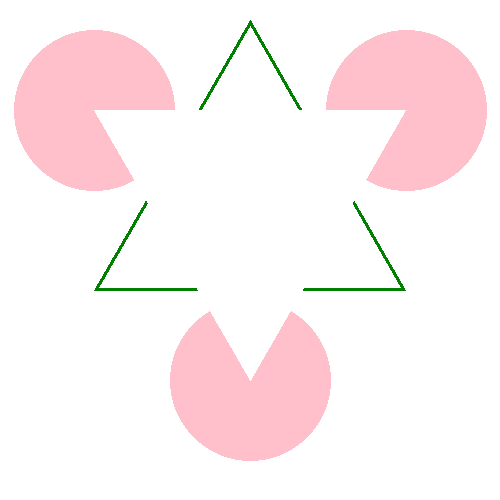

In [7]:
# drawing Kanizsa triangle

# some utilities
def rot2d(angle):
  return np.array([[np.cos(angle), -np.sin(angle)],
                   [np.sin(angle), np.cos(angle)]])
size = 500
center = np.array((size/2, size/2 * 4/5)) # some correction so the triangle fits
unit_x = np.array([1,0])

# actual drawing
img = Image.new("RGB", (size, size), "white")
draw = ImageDraw.Draw(img)

ref_circ_radius = 180
circ_radius = 80

omega_0 = np.pi/2
angles = [omega_0, omega_0 - 2/3 * np.pi, omega_0 - 4/3 * np.pi]
c0 = np.round((rot2d(angles[0]) @ unit_x) * ref_circ_radius + center).tolist()
c1 = np.round((rot2d(angles[1]) @ unit_x) * ref_circ_radius + center).tolist()
c2 = np.round((rot2d(angles[2]) @ unit_x) * ref_circ_radius + center).tolist()

draw.circle(c0, radius=circ_radius, fill="pink")
draw.circle(c1, radius=circ_radius, fill="pink")
draw.circle(c2, radius=circ_radius, fill="pink")
draw.regular_polygon(
    bounding_circle=(center.tolist(), ref_circ_radius),
    n_sides=3,
    outline="green",
    width = 3,
    rotation=0
    )
draw.regular_polygon(
    bounding_circle=(center.tolist(), ref_circ_radius),
    n_sides=3,
    fill="white",
    rotation=180
    )

img.save("kanizsa.png")
img

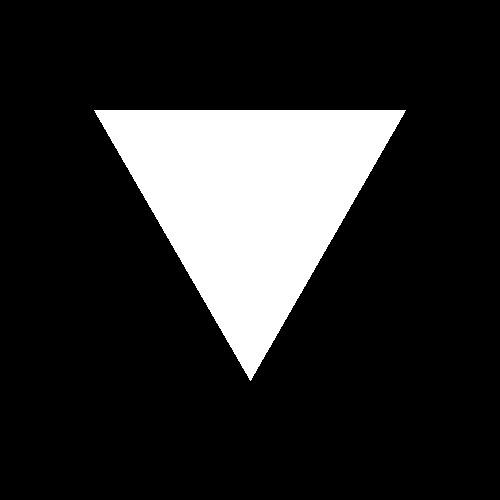

In [8]:
# drawing the mask of inpainting

img = Image.new("RGB", (size, size), "black")
draw = ImageDraw.Draw(img)

draw.regular_polygon(
    bounding_circle=(center.tolist(), ref_circ_radius),
    n_sides=3,
    fill="white",
    rotation=180
    )

img.save("kanizsa_mask.png")
img

In [15]:
def read_image(path, *, mask=False, grayscale=False, LAB=False):
  "Open and parse image file as a numpy array to process"
  img = Image.open(path)
  if grayscale:
    img = img.convert("L")
    arr = np.array(img)
    return arr/arr.max()
  if mask:
    img = img.convert("1") # masks are just boolean arrays
    return np.array(img)
  if LAB:
    img = img.convert("LAB")
    return np.array(img)

  return np.array(img.convert("RGB"))

In [16]:
def display_img(array, LAB=False):
  if np.issubdtype(array.dtype,float) and len(array.shape) == 2:
    display(Image.fromarray(255 * array / array.max()).convert("L"))
  elif np.issubdtype(array.dtype,bool) and len(array.shape) == 2:
    display(Image.fromarray(array))
  else:
    display(Image.fromarray(array, mode="LAB" if LAB else "RGB").convert("RGB"))

In [18]:
def pad_image(img,  horizontal_pad_size, vertical_pad_size):
  """creates a padded image by repeating the margins"""
  # the corner will just be the corner pixel as a square
  def gen_corner_pad(value):
    return np.full(
        shape=(horizontal_pad_size, vertical_pad_size, *img.shape[2:]),
        fill_value = value,
        dtype = img.dtype,
    )

  new_img = img

  if vertical_pad_size > 0:
    #pad above

    # this line needs some shape casting to keep the array bidimensional
    # that is shape == (1, width) rathern than shape == (width, )
    upper_row = img[0,:].reshape((1,*img.shape[1:]))
    above_pad = np.repeat(upper_row, vertical_pad_size, axis=0)

    # pad bottom

    bottom_row = img[-1,:].reshape((1, *img.shape[1:]))
    bottom_pad = np.repeat(bottom_row, vertical_pad_size, axis=0)

    new_img = np.vstack([above_pad,
                         new_img,
                         bottom_pad])

  if horizontal_pad_size > 0:

    # pad left
    left_column = img[:,0].reshape((img.shape[0], 1, *img.shape[2:]))
    left_pad = np.repeat(left_column, horizontal_pad_size, axis=1)

    # pad right
    right_column = img[:,-1].reshape((img.shape[0], 1, *img.shape[2:]))
    right_pad = np.repeat(right_column, horizontal_pad_size, axis=1)

    if vertical_pad_size > 0:
      left_pad = np.vstack([gen_corner_pad(img[0,0]),
                            left_pad,
                            gen_corner_pad(img[-1,0])])

      right_pad = np.vstack([gen_corner_pad(img[0,-1]),
                             right_pad,
                             gen_corner_pad(img[-1,-1])])

    new_img = np.hstack([left_pad, new_img, right_pad])

  return new_img

In [19]:
def convolve(img, ker, op=np.sum,where=True):
  """
  convolution of a kernel and and an image, change op for numpy acc
  operations like mean, prod or sum, default=sum
  """
  vertical_pad_size = int(ker.shape[0]//2)
  horizontal_pad_size = int(ker.shape[1]//2)
  padded_img = pad_image(img, horizontal_pad_size, vertical_pad_size)
  windows = sliding_window_view(padded_img, (*ker.shape,*img.shape[2:]))
  convolved = op(windows * ker[np.newaxis, np.newaxis, :],axis=(2,3), where=where)
  return convolved

In [20]:
# sobel gradient
def sobel_grad(img):
  sobel_x = np.array([[-1, 0, +1],
                      [-2, 0, +2],
                      [-1, 0, +1]])
  sobel_y = sobel_x.T

  dx = convolve(img, sobel_x)
  dy = convolve(img, sobel_y)
  grad = np.stack([dx,dy], axis=2)
  return grad

In [23]:
class Inpainting:
  def __init__(self, image_rgb, target_mask, texel_side):
    assert len(image_rgb.shape) == 3, "The image must be a 3-dim array"
    assert image_rgb.shape[2] == 3, "Last dimension must correspond to the rgb channels"
    assert np.issubdtype(image_rgb.dtype,np.uint8), "The image must have type uint8"
    self.img_rgb = image_rgb
    self.img_shape = image_rgb.shape[:2]

    assert np.issubdtype(target_mask.dtype,bool), "The inpainting area mask must be boolean"
    assert len(target_mask.shape) == 2, "The inpainting area mask must be a 2-dim array"
    assert target_mask.shape == image_rgb.shape[:2], "The inpainting area mask must have the same size as the image"
    self.tgt_mask = target_mask
    self.src_mask = np.logical_not(target_mask)

    # zero the target area in the rgb image / cannot use nan since dtype == np.uint8
    self.img_rgb[self.tgt_mask] = np.array([0,0,0])

    assert texel_side % 2 == 1, "Texel side must be odd"
    self.texel_side = texel_side
    self.texel_rad = int(texel_side//2)

    self.current_iteration = 0


  def inspect_texel(self,arr,x,y):
    "for debugging"
    texel_slice = [slice(y-self.texel_rad,y+self.texel_rad+1),
                   slice(x-self.texel_rad,x+self.texel_rad+1)]

    return arr[*texel_slice]

  def update_img_gray(self):
    """
    ITU-R 601-2 luma transform:
    > L = R * 299/1000 + G * 587/1000 + B * 114/1000
    The values inside the inpainting area are Nan
    """
    # implemented to match Pillow/cv2 behavior
    # ITU-R Recommendation 601-2 for nonlinear RGB
    # scaled to 24 bits
    img_rgb_float = self.img_rgb.astype(np.uint32)
    gray = 19595 * img_rgb_float[:,:,0] + \
           38470 * img_rgb_float[:,:,1] + \
           7471 * img_rgb_float[:,:,2] + \
           0x8000

    gray = gray >> 16
    gray = gray / 255
    gray[self.tgt_mask] = np.nan
    self.img_gray = gray


  def update_img_lab(self):
    self.img_lab = np.array(Image.fromarray(self.img_rgb).convert("LAB"))


  def update_texels_lab(self):
    padded_img = pad_image(self.img_lab,self.texel_rad, self.texel_rad)
    texels = sliding_window_view(
        padded_img,
        window_shape=(self.texel_side, self.texel_side, 3)
        )

    self.texels_lab = texels.reshape((*self.img_shape, self.texel_side, self.texel_side, 3))


  def update_tgt_mask_grad(self):
    self.tgt_mask_grad = sobel_grad(self.tgt_mask)


  def update_contour_mask(self):
    "Mask of the contour on the side of the source area"
    # we just choose the pixels where the mask has a gradient
    masked_grad = self.src_mask[:,:, np.newaxis] * self.tgt_mask_grad
    masked_grad_norm = np.linalg.norm(masked_grad, axis=2)
    self.contour_mask = masked_grad_norm > 0

  def update_contour_normal(self):
    "Normal vectors on the contour"
    masked_grad = self.contour_mask[:,:, np.newaxis] * self.tgt_mask_grad
    masked_grad_norm = np.linalg.norm(masked_grad, axis=2)[:,:,np.newaxis]
    self.contour_normal = np.divide(masked_grad,masked_grad_norm, where=masked_grad_norm > 0)

  def update_img_gray_grad(self):
    """
    Sobel gradient of the grayscaled image. Nan values inside the target area
    and averaged values for the gradient in the contour.
    """
    grad = sobel_grad(self.img_gray)
    # since the  convolution included nan values for the contour pixels, these
    # are nan right now

    # to fill in the gradients in the border we are going to average over
    # a moving window
    contour_grad_x = convolve(
        grad[:,:,0],
        np.ones((self.texel_side, 1)), # a column of ones
        op=np.nanmean, # average ignoring nans (note that the grad is nan on the border)
        where=self.contour_mask[:,:,np.newaxis,np.newaxis] # for a little performance
        )
    contour_grad_y = convolve(
        grad[:,:,1],
        np.ones((1,self.texel_side)), # a row of ones
        op=np.nanmean,
        where=self.contour_mask[:,:,np.newaxis,np.newaxis] # for a little performance
        )
    # sometimes there are not enough values to get an actual gradient average
    # that is, the windows is just nans
    contour_grad_x = np.nan_to_num(contour_grad_x, nan=0)
    contour_grad_y = np.nan_to_num(contour_grad_y, nan=0)

    grad[self.contour_mask,0] = contour_grad_x[self.contour_mask]
    grad[self.contour_mask,1] = contour_grad_y[self.contour_mask]

    self.img_gray_grad = grad

  def update_isophote(self):
    isophote_rot = self.img_gray_grad * self.contour_mask[:,:,np.newaxis]
    isophote_rot = isophote_rot[:,:,:,np.newaxis]
    self.isophote = rot2d(np.pi/2) @ isophote_rot

  def update_data_value(self):
    contour_normals_cols = self.contour_normal.reshape((*self.contour_normal.shape,1)) # column vectors
    isophotes_rows = self.isophote.reshape((*self.isophote.shape[:2],1,2)) # row vectors
    data_values = np.abs(isophotes_rows @ contour_normals_cols).reshape(self.img_shape)
    self.data_value = data_values
    #TODO: missing dividing by alpha

  def init_confidence(self):
    self.confidence = self.src_mask * 1.0

  def update_confidence(self):
    padded_confidence = pad_image(self.confidence,self.texel_rad, self.texel_rad)
    texels_confidence = sliding_window_view(
        padded_confidence,
        window_shape=(self.texel_side, self.texel_side)
        )

    self.confidence = np.nansum(
        texels_confidence,
        axis=(2,3),
        where=self.contour_mask[:,:,np.newaxis,np.newaxis]
        )
    self.confidence = self.confidence / (self.texel_side * self.texel_side)

  def update_priority(self):
    self.priority = self.confidence * self.data_value

  def update_chosen_point(self):
    "This results in the array cordinates (y,x) or (row,col) of the patch chosen to inpaint"
    priority_without_nan = np.nan_to_num(self.priority, nan=-np.inf)
    # restrict to contour
    priority_without_nan[np.logical_not(self.contour_mask)] = - np.inf
    index = np.argmax(priority_without_nan, axis=None)
    self.chosen_point = np.unravel_index(index, self.img_shape)

  def update_chosen_texel_lab(self):
    self.chosen_texel_lab = self.texels_lab[self.chosen_point].copy()
    # first y then x (row, column order)


    self.chosen_texel_slice = [slice(self.chosen_point[0] - self.texel_rad,
                                     self.chosen_point[0] + self.texel_rad + 1),
                               slice(self.chosen_point[1] - self.texel_rad,
                                     self.chosen_point[1] + self.texel_rad + 1)]

  def update_texel_change_mask(self):
    "A mask for the values of the chosen texel that will change"
    self.texel_change_mask = self.tgt_mask[*self.chosen_texel_slice]


  def update_texel_lab_distances(self):
    "Compare the chosen texel with all other texels, only compare already known values"
    # TODO: this should probably be scaled so we priviledge closer pixels
    # also probably pixels with higher confidence should be more likely
    distances = (self.texels_lab - self.chosen_texel_lab)
    # ignore comparing unknown values, we use the oposite of the texel change mask
    distances = distances * (np.logical_not(self.texel_change_mask)[np.newaxis,np.newaxis,:,:,np.newaxis])
    distances = distances.reshape((*self.img_shape,self.texel_side * self.texel_side * 3))
    distances = np.linalg.norm(distances, axis=2)
    distances[self.tgt_mask] = np.inf
    distances[self.contour_mask] = np.inf

    # Ignore invalid texels - artifact from padding the image to keep the
    # dimensions in the windows view
    distances[:self.texel_rad,:] = np.inf
    distances[-self.texel_rad:,:] = np.inf
    distances[:,:self.texel_rad] = np.inf
    distances[:,-self.texel_rad:] = np.inf
    self.texel_lab_distances  = distances

  def update_reference_point(self):
    "This results in the array cordinates (y,x) or (row,col) of the patch chosen to copy"
    self.reference_point = np.unravel_index(np.argmin(self.texel_lab_distances, axis=None), self.img_shape)

  def update_reference_texel_lab(self):
    self.reference_texel_lab = self.texels_lab[self.reference_point].copy()
    # first y then x (row, column order)
    self.reference_texel_slice = [slice(self.reference_point[0] - self.texel_rad,
                                     self.reference_point[0] + self.texel_rad + 1),
                                  slice(self.reference_point[1] - self.texel_rad,
                                     self.reference_point[1] + self.texel_rad + 1)]

  def update_img_rgb_with_new_patch(self):
    self.img_rgb[*self.chosen_texel_slice] = self.img_rgb[*self.reference_texel_slice]
  def update_tgt_mask_with_new_patch(self):
    self.tgt_mask[*self.chosen_texel_slice] = False
    self.src_mask = np.logical_not(self.tgt_mask)

/tmp/ipython-input-3505220629.py:10: RuntimeWarning: Mean of empty slice
  convolved = op(windows * ker[np.newaxis, np.newaxis, :],axis=(2,3), where=where)




ITERATION 0

test.max()=np.float64(255.0),prio.max()=np.float64(1.5873393745158921)
test.max()=np.float64(255.0),prio.max()=np.float64(1.0)
test.shape=(500, 500, 3),prio.shape=(500, 500, 3)
test.max()=np.float64(255.0),prio.max()=np.float64(255.0)


/tmp/ipython-input-935180120.py:7: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  display(Image.fromarray(array, mode="LAB" if LAB else "RGB").convert("RGB"))


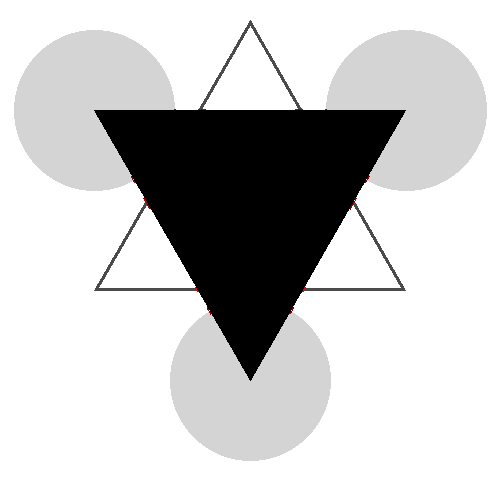

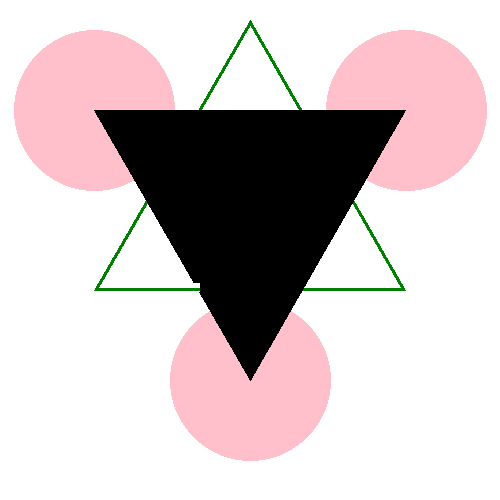



ITERATION 10

test.max()=np.float64(255.0),prio.max()=np.float64(1.2369507275678318e-08)
test.max()=np.float64(255.0),prio.max()=np.float64(1.0)
test.shape=(500, 500, 3),prio.shape=(500, 500, 3)
test.max()=np.float64(255.0),prio.max()=np.float64(255.0)


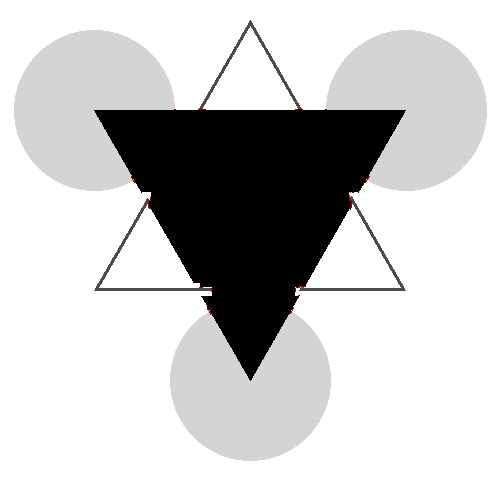

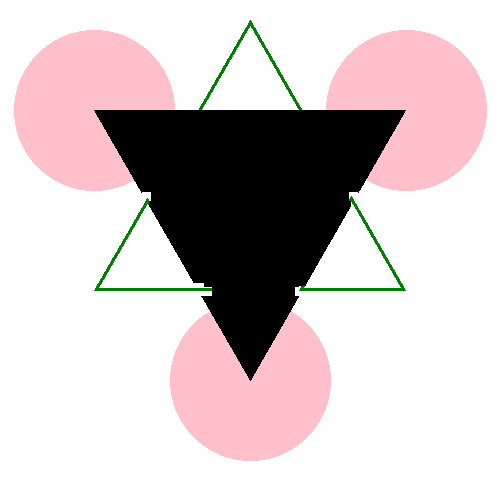



ITERATION 20

test.max()=np.float64(255.0),prio.max()=np.float64(1.0224239950746176e-15)
test.max()=np.float64(255.0),prio.max()=np.float64(1.0)
test.shape=(500, 500, 3),prio.shape=(500, 500, 3)
test.max()=np.float64(255.0),prio.max()=np.float64(255.0)


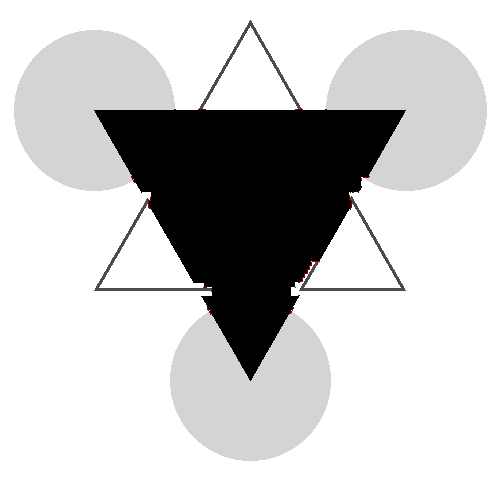

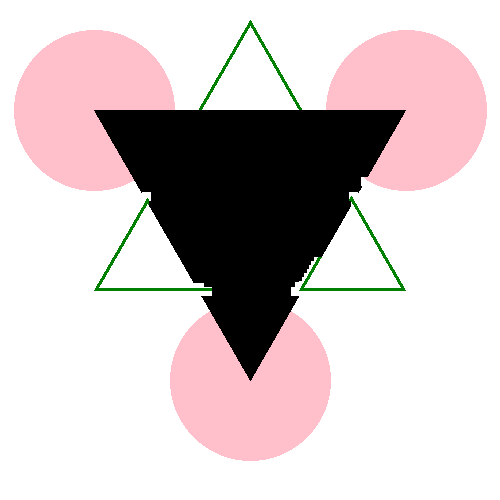



ITERATION 30

test.max()=np.float64(255.0),prio.max()=np.float64(2.2999632847522755e-23)
test.max()=np.float64(255.0),prio.max()=np.float64(1.0)
test.shape=(500, 500, 3),prio.shape=(500, 500, 3)
test.max()=np.float64(255.0),prio.max()=np.float64(255.0)


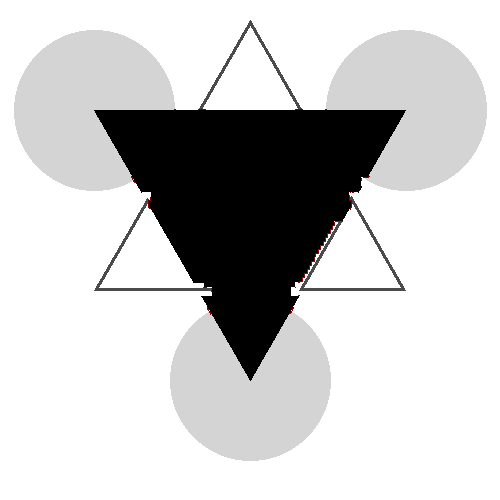

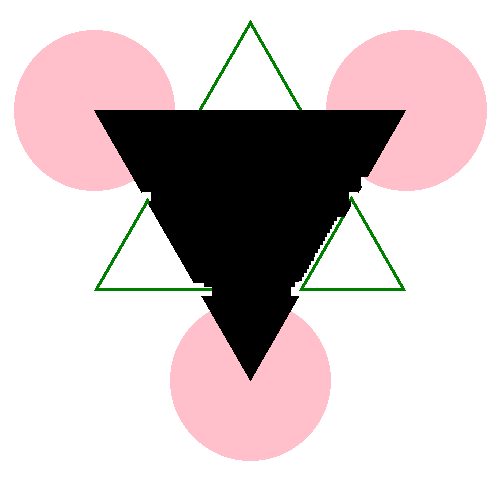



ITERATION 40

test.max()=np.float64(255.0),prio.max()=np.float64(1.779297588670698e-31)
test.max()=np.float64(255.0),prio.max()=np.float64(1.0)
test.shape=(500, 500, 3),prio.shape=(500, 500, 3)
test.max()=np.float64(255.0),prio.max()=np.float64(255.0)


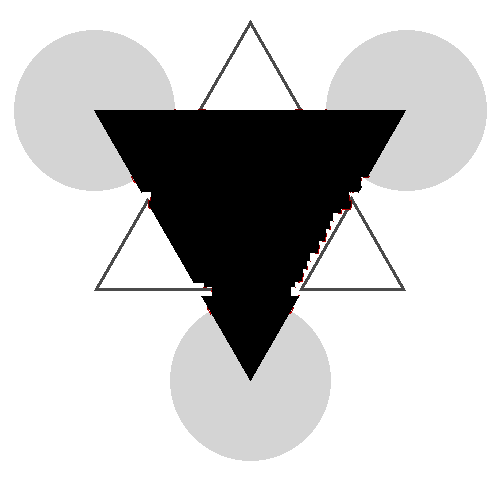

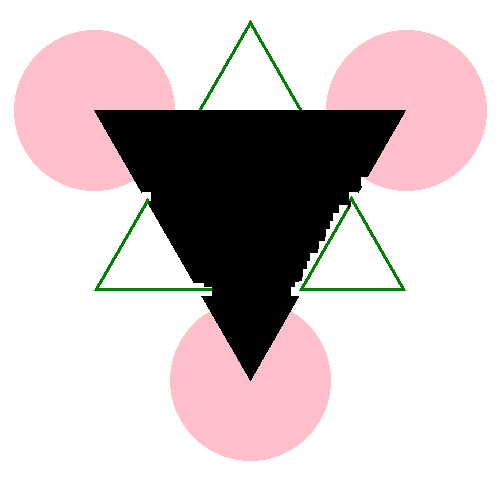



ITERATION 50

test.max()=np.float64(255.0),prio.max()=np.float64(1.4365477017784338e-39)
test.max()=np.float64(255.0),prio.max()=np.float64(1.0)
test.shape=(500, 500, 3),prio.shape=(500, 500, 3)
test.max()=np.float64(255.0),prio.max()=np.float64(255.0)


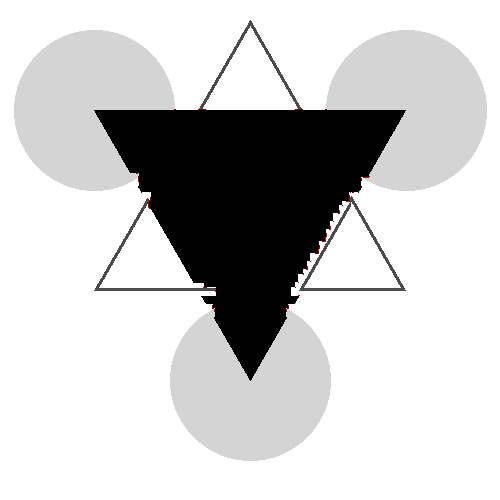

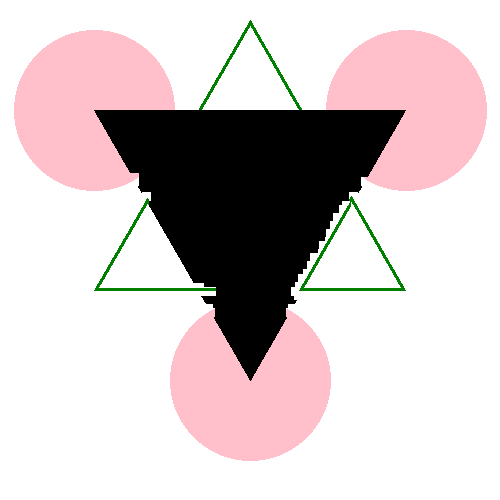

In [39]:
img = read_image("kanizsa.png")
mask = read_image("kanizsa_mask.png", mask = True)
i = Inpainting(img, mask, 9)

i.init_confidence()

for it in range(50+1):
  i.update_img_gray()
  i.update_img_lab()
  i.update_texels_lab()

  i.update_tgt_mask_grad()
  i.update_contour_mask()
  i.update_contour_normal()

  i.update_img_gray_grad()
  i.update_isophote()

  i.update_data_value()
  i.update_confidence()

  i.update_priority()

  i.update_chosen_point()
  i.update_chosen_texel_lab()
  i.update_texel_change_mask()
  i.update_texel_lab_distances()
  i.update_reference_point()
  i.update_reference_texel_lab()

  i.update_img_rgb_with_new_patch()
  i.update_tgt_mask_with_new_patch()

  if it % 10 == 0:
    print(f"\n\nITERATION {it}\n")
    test = np.nan_to_num(i.img_gray)[:,:,np.newaxis] * np.array([[[1,1,1]]]) * 255
    prio = np.nan_to_num(i.priority)
    prio_mask = prio > 0
    print(f'{test.max()=},{prio.max()=}')
    prio = prio / prio.max()
    print(f'{test.max()=},{prio.max()=}')
    prio = prio[:,:,np.newaxis] * np.array([[[1,0,0]]]) * 127 + np.array([[[128, 0, 0]]])
    print(f'{test.shape=},{prio.shape=}')
    print(f'{test.max()=},{prio.max()=}')
    test[prio_mask] = prio[prio_mask]
    test = test.astype(np.uint8)



    display_img(test)
    display_img(i.img_rgb)

/tmp/ipython-input-3505220629.py:10: RuntimeWarning: Mean of empty slice
  convolved = op(windows * ker[np.newaxis, np.newaxis, :],axis=(2,3), where=where)




ITERATION 0



/tmp/ipython-input-935180120.py:7: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  display(Image.fromarray(array, mode="LAB" if LAB else "RGB").convert("RGB"))


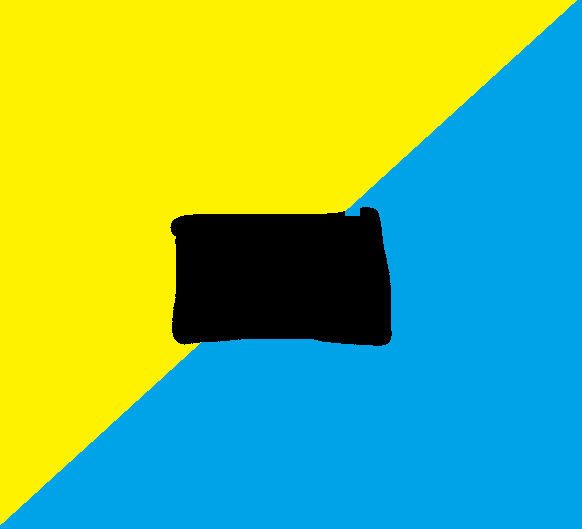



ITERATION 10



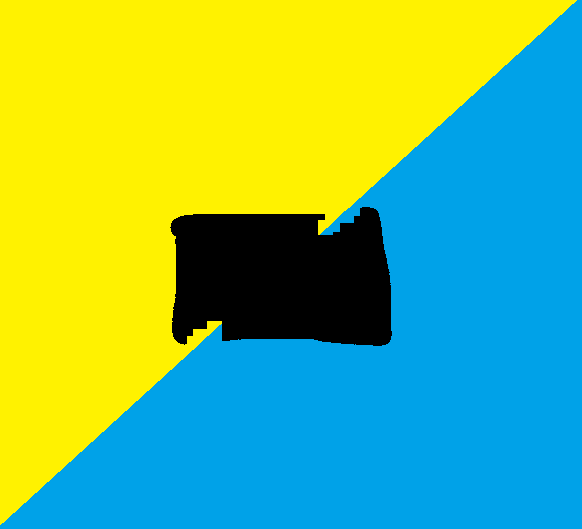



ITERATION 20



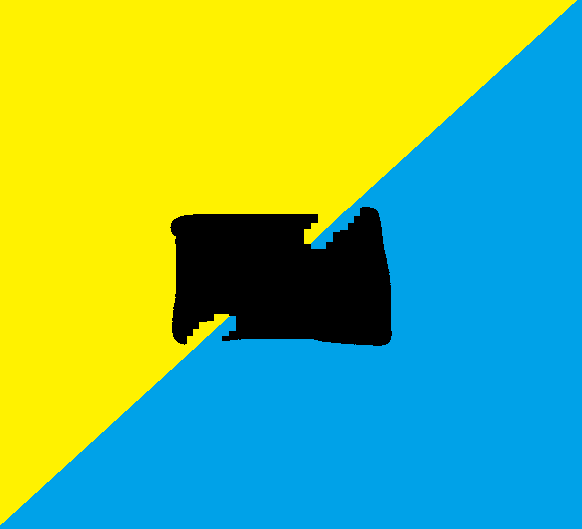



ITERATION 30



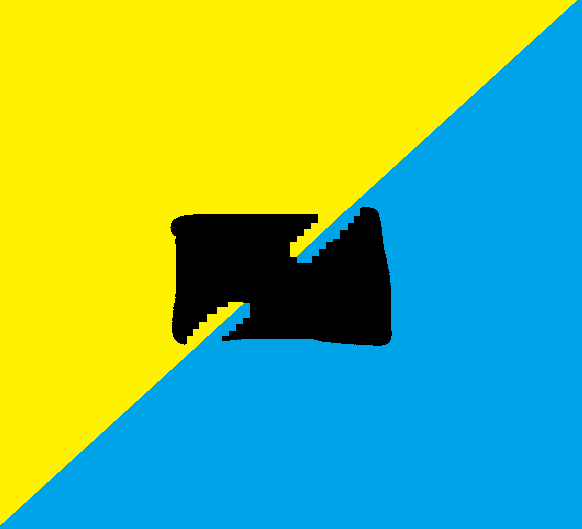



ITERATION 40



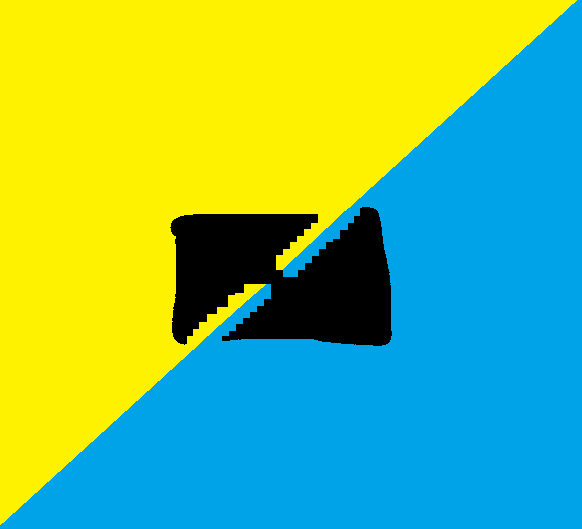



ITERATION 50



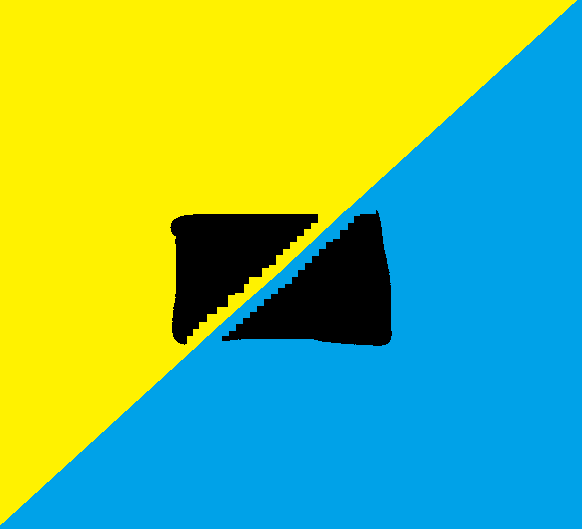



ITERATION 60



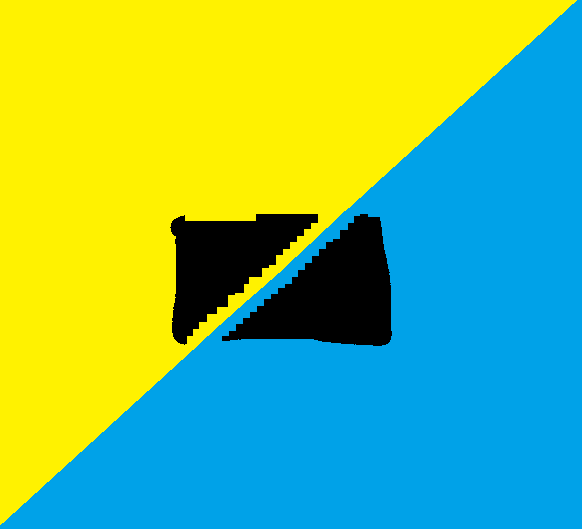



ITERATION 70



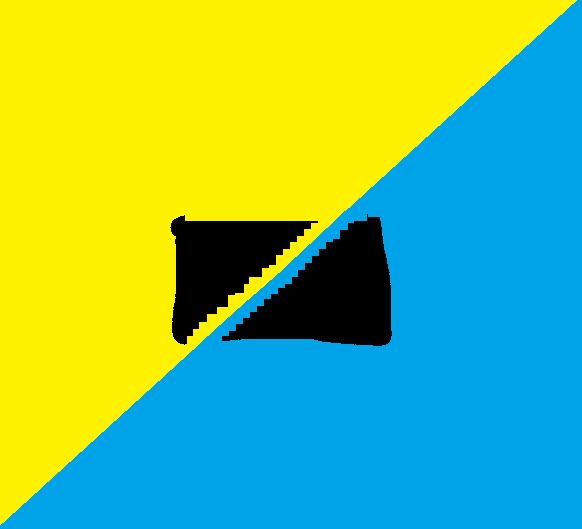



ITERATION 80



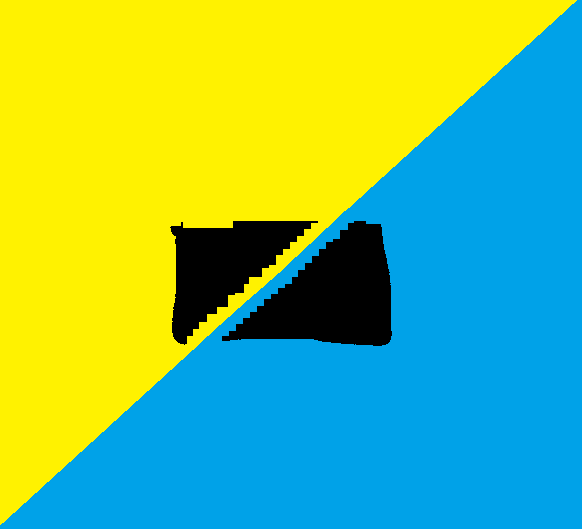



ITERATION 90



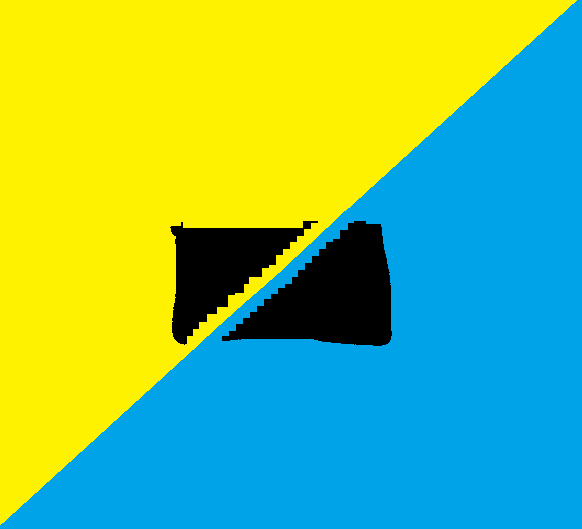



ITERATION 100



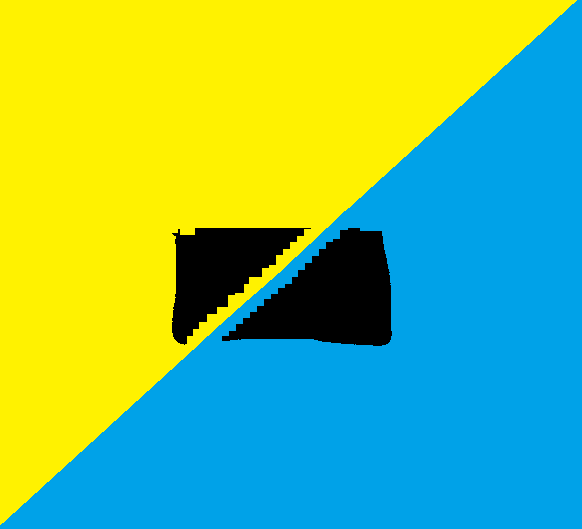

In [38]:
img = read_image("image_incomplete.png")
mask = read_image("mask.png", mask = True)
i = Inpainting(img, mask, 15)

i.init_confidence()

for it in range(100+1):
  i.update_img_gray()
  i.update_img_lab()
  i.update_texels_lab()

  i.update_tgt_mask_grad()
  i.update_contour_mask()
  i.update_contour_normal()

  i.update_img_gray_grad()
  i.update_isophote()

  i.update_data_value()
  i.update_confidence()

  i.update_priority()

  i.update_chosen_point()
  i.update_chosen_texel_lab()
  i.update_texel_change_mask()
  i.update_texel_lab_distances()
  i.update_reference_point()
  i.update_reference_texel_lab()

  i.update_img_rgb_with_new_patch()
  i.update_tgt_mask_with_new_patch()

  if it % 10 == 0:
    print(f"\n\nITERATION {it}\n")
    display_img(i.img_rgb)